# Notebook 3 — AI Object Detection

- each code cell starts with a **Parameters** section when relevant  
- student exercise cells contain `None` or `NotImplementedError` to complete  
- the notebook goes from **one image** → **interpreting detections** → **live camera demos**  
- the final sections are **optional extensions** using face detection / face mesh

This notebook introduces the idea of using a **pretrained AI model** to detect objects and faces.


In [1]:
# ============================================
# Setup
# Goal:
# Load the libraries used in the notebook.
# ============================================

import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import mediapipe as mp

plt.rcParams["figure.figsize"] = (8, 6)


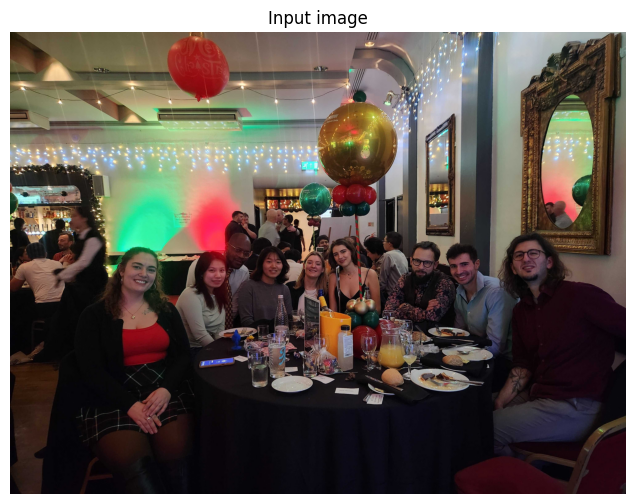

In [6]:
# ============================================
# Load a real image
# Goal:
# Read an image from disk and display it.
# ============================================

# --- Parameters ---
IMAGE_PATH = "../images/lab_photo.png"
FIGSIZE = (8, 6)

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=FIGSIZE)
plt.imshow(img_rgb)
plt.title("Input image")
plt.axis("off")
plt.show()


In [7]:
# ============================================
# Load a pretrained object detector
# Goal:
# Use a YOLO model that already knows many common objects.
# ============================================

# --- Parameters ---
MODEL_PATH = "yolov8n.pt"

model = YOLO(MODEL_PATH)
print("Model loaded:", MODEL_PATH)


Model loaded: yolov8n.pt


In [8]:
# ============================================
# Run object detection on one image
# Goal:
# Ask the model to find objects in the image.
# ============================================

# --- Parameters ---
CONFIDENCE_THRESHOLD = 0.25

results = model(img_bgr, conf=CONFIDENCE_THRESHOLD, verbose=False)
result = results[0]

print("Number of detections:", len(result.boxes))


Number of detections: 23


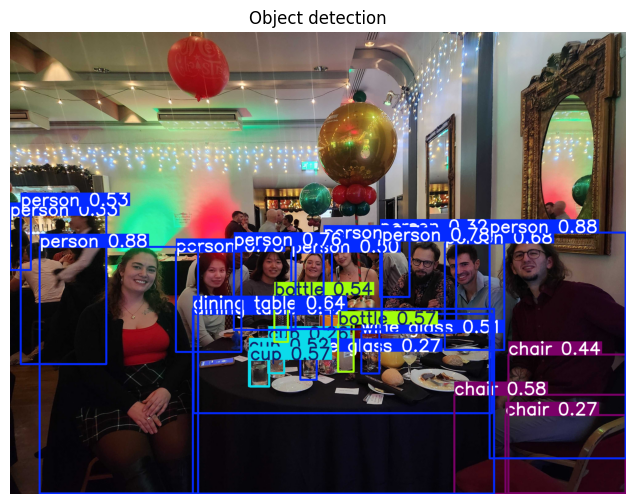

In [9]:
# ============================================
# Display the detections
# Goal:
# Visualize the predicted boxes and labels.
# ============================================

annotated_bgr = result.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_rgb)
plt.title("Object detection")
plt.axis("off")
plt.show()


In [10]:
# ============================================
# Example: inspect the detected objects
# Goal:
# Read the class, confidence, and box coordinates.
# ============================================

for i, box in enumerate(result.boxes):
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(
        f"{i:02d} | "
        f"class={model.names[cls_id]:<12} "
        f"confidence={conf:.2f} "
        f"box=({x1:.0f}, {y1:.0f}) → ({x2:.0f}, {y2:.0f})"
    )


00 | class=person       confidence=0.88 box=(3115, 1303) → (3997, 2769)
01 | class=person       confidence=0.88 box=(192, 1395) → (1221, 2996)
02 | class=person       confidence=0.78 box=(2415, 1355) → (2897, 1953)
03 | class=person       confidence=0.76 box=(1454, 1385) → (1854, 1935)
04 | class=person       confidence=0.73 box=(1078, 1427) → (1502, 2077)
05 | class=person       confidence=0.71 box=(2036, 1339) → (2413, 1930)
06 | class=person       confidence=0.68 box=(2823, 1373) → (3209, 2064)
07 | class=dining table confidence=0.64 box=(1187, 1797) → (3143, 2998)
08 | class=chair        confidence=0.58 box=(2886, 2356) → (4000, 2998)
09 | class=cup          confidence=0.57 box=(1559, 2128) → (1683, 2302)
10 | class=bottle       confidence=0.57 box=(2131, 1898) → (2232, 2205)
11 | class=bottle       confidence=0.54 box=(1716, 1708) → (1804, 2012)
12 | class=person       confidence=0.53 box=(70, 1128) → (626, 2156)
13 | class=cup          confidence=0.52 box=(1552, 2072) → (1682, 23

In [17]:
# ============================================
# Example: keep only high-confidence detections
# Goal:
# Show how a confidence threshold changes the output.
# ============================================

# --- Parameters ---
HIGH_CONFIDENCE_THRESHOLD = 0.60

high_conf_labels = []

for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    if conf >= HIGH_CONFIDENCE_THRESHOLD:
        high_conf_labels.append((model.names[cls_id], round(conf, 2)))

print("High-confidence detections:")
for label, conf in high_conf_labels:
    print("-", label, conf)


High-confidence detections:
- person 0.88
- person 0.88
- person 0.78
- person 0.76
- person 0.73
- person 0.71
- person 0.68
- dining table 0.64


In [21]:
# ============================================
# 📹 Live YOLO detection
# Goal:
# Detect common objects in the camera feed.
# Press q to stop early.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live YOLO Detection"
LIVE_MODEL_PATH = "yolov8n.pt"
CONFIDENCE_THRESHOLD = 0.5

cap = cv2.VideoCapture(CAMERA_INDEX)
live_model = YOLO(LIVE_MODEL_PATH)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            live_results = live_model(frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
            annotated = live_results[0].plot()

            cv2.imshow(WINDOW_NAME, annotated)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)


In [23]:
# ============================================
# 📹 Live face detection
# Goal:
# Detect faces in the camera feed and display them.
# This is not the same as object detection:
# here we use a specialised face detector.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 5
WINDOW_NAME = "Live Face Detection"
MODEL_SELECTION = 1
MIN_DETECTION_CONFIDENCE = 0.5
DRAW_DETECTIONS = True

mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_detection.FaceDetection(
        model_selection=MODEL_SELECTION,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE
    ) as face_detection:

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                detection_results = face_detection.process(rgb)

                if DRAW_DETECTIONS and detection_results.detections:
                    for detection in detection_results.detections:
                        mp_drawing.draw_detection(frame, detection)

                cv2.imshow(WINDOW_NAME, frame)

                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)


I0000 00:00:1774017986.999807 3241997 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774017987.078755 3246807 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
# ============================================
# STUDENT TASK 3
# Goal:
# Modify the live face detector.
# Try one of these:
# 1) increase DISPLAY_SECONDS
# 2) change MODEL_SELECTION (options: 0 or 1)
# 3) turn DRAW_DETECTIONS on/off
# ============================================

raise NotImplementedError("Edit the parameters or code in the previous cell, then rerun it.")


In [24]:
# ============================================
# 📹 Optional extension: stylised face filter
# Goal:
# Use MediaPipe Face Mesh landmarks to draw overlays
# that follow the face in real time.
# ============================================

# import cv2
# import mediapipe as mp
# import time
# import numpy as np

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 15
WINDOW_NAME = "Face Filter"

MAX_NUM_FACES = 1
MIN_DETECTION_CONFIDENCE = 0.5
MIN_TRACKING_CONFIDENCE = 0.5
MIRROR_VIEW = True

DRAW_EYE_OUTLINE = True
DRAW_EYE_FILL = True
DRAW_EYEBROWS = True
DRAW_LIP_OUTLINE = True
DRAW_LIP_FILL = True
DRAW_CAT_EARS = False
DRAW_LANDMARKS = False

EYE_COLOR = (180, 80, 30)
EYE_OUTLINE_THICKNESS = 2
EYE_ALPHA = 0.08

EYEBROW_COLOR = (40, 30, 20)
EYEBROW_OUTLINE_THICKNESS = 2
EYEBROW_ALPHA = 0.25
EYEBROW_THICKNESS_PX = 20

LIP_COLOR = (80, 80, 220)
LIP_OUTLINE_THICKNESS = 2
LIP_ALPHA = 0.22

EAR_OUTER_COLOR = (160, 190, 255)
EAR_INNER_COLOR = (180, 210, 255)
EAR_OUTLINE_COLOR = (90, 120, 200)
EAR_ALPHA = 0.85

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

LEFT_EYE_OUTLINE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_OUTLINE = [362, 385, 387, 263, 373, 380]
LEFT_EYEBROW = [70, 63, 105, 66, 107]
RIGHT_EYEBROW = [336, 296, 334, 293, 300]
OUTER_LIPS = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375,
              291, 409, 270, 269, 267, 0, 37, 39, 40, 185]
INNER_LIPS = [78, 95, 88, 178, 87, 14, 317, 402, 318, 324,
              308, 415, 310, 311, 312, 13, 82, 81, 80, 191]

def to_px(landmark, w, h):
    return np.array([int(landmark.x * w), int(landmark.y * h)])

def pts_from_indices(landmarks, indices, w, h):
    return np.array([to_px(landmarks[i], w, h) for i in indices], dtype=np.int32)

def thicken_polyline(poly, offset_y):
    shifted = poly + np.array([0, offset_y])
    return np.vstack([poly, shifted[::-1]])

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_mesh.FaceMesh(
        static_image_mode=False,
        max_num_faces=MAX_NUM_FACES,
        refine_landmarks=True,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE,
        min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
    ) as face_mesh:

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if MIRROR_VIEW:
                    frame = cv2.flip(frame, 1)

                h, w, _ = frame.shape
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mesh_results = face_mesh.process(rgb)

                if mesh_results.multi_face_landmarks:
                    for face_landmarks in mesh_results.multi_face_landmarks:
                        lm = face_landmarks.landmark

                        if DRAW_LANDMARKS:
                            mp_drawing.draw_landmarks(
                                frame,
                                face_landmarks,
                                mp_face_mesh.FACEMESH_TESSELATION
                            )

                        left_eye = pts_from_indices(lm, LEFT_EYE_OUTLINE, w, h)
                        right_eye = pts_from_indices(lm, RIGHT_EYE_OUTLINE, w, h)
                        left_eyebrow_line = pts_from_indices(lm, LEFT_EYEBROW, w, h)
                        right_eyebrow_line = pts_from_indices(lm, RIGHT_EYEBROW, w, h)
                        outer_lips = pts_from_indices(lm, OUTER_LIPS, w, h)
                        inner_lips = pts_from_indices(lm, INNER_LIPS, w, h)

                        left_face = to_px(lm[234], w, h)
                        right_face = to_px(lm[454], w, h)
                        forehead = to_px(lm[10], w, h)

                        if DRAW_EYE_FILL:
                            eye_overlay = frame.copy()
                            cv2.fillPoly(eye_overlay, [left_eye], EYE_COLOR)
                            cv2.fillPoly(eye_overlay, [right_eye], EYE_COLOR)
                            frame = cv2.addWeighted(eye_overlay, EYE_ALPHA, frame, 1 - EYE_ALPHA, 0)

                        if DRAW_EYE_OUTLINE:
                            cv2.polylines(frame, [left_eye], True, EYE_COLOR, EYE_OUTLINE_THICKNESS, cv2.LINE_AA)
                            cv2.polylines(frame, [right_eye], True, EYE_COLOR, EYE_OUTLINE_THICKNESS, cv2.LINE_AA)

                        if DRAW_EYEBROWS:
                            left_brow_poly = thicken_polyline(left_eyebrow_line, EYEBROW_THICKNESS_PX)
                            right_brow_poly = thicken_polyline(right_eyebrow_line, EYEBROW_THICKNESS_PX)

                            brow_overlay = frame.copy()
                            cv2.fillPoly(brow_overlay, [left_brow_poly], EYEBROW_COLOR)
                            cv2.fillPoly(brow_overlay, [right_brow_poly], EYEBROW_COLOR)
                            frame = cv2.addWeighted(brow_overlay, EYEBROW_ALPHA, frame, 1 - EYEBROW_ALPHA, 0)

                            cv2.polylines(frame, [left_brow_poly], True, EYEBROW_COLOR, EYEBROW_OUTLINE_THICKNESS, cv2.LINE_AA)
                            cv2.polylines(frame, [right_brow_poly], True, EYEBROW_COLOR, EYEBROW_OUTLINE_THICKNESS, cv2.LINE_AA)

                        if DRAW_LIP_FILL:
                            lip_overlay = frame.copy()
                            cv2.fillPoly(lip_overlay, [outer_lips], LIP_COLOR)
                            cv2.fillPoly(lip_overlay, [inner_lips], (0, 0, 0))
                            frame = cv2.addWeighted(lip_overlay, LIP_ALPHA, frame, 1 - LIP_ALPHA, 0)

                        if DRAW_LIP_OUTLINE:
                            cv2.polylines(frame, [outer_lips], True, LIP_COLOR, LIP_OUTLINE_THICKNESS, cv2.LINE_AA)
                            cv2.polylines(frame, [inner_lips], True, LIP_COLOR, 1, cv2.LINE_AA)

                        if DRAW_CAT_EARS:
                            face_width = max(1, abs(right_face[0] - left_face[0]))
                            ear_height = int(0.30 * face_width)
                            ear_width = int(0.18 * face_width)

                            left_base = (left_face[0] + int(0.18 * face_width), forehead[1] - int(0.08 * face_width))
                            right_base = (right_face[0] - int(0.18 * face_width), forehead[1] - int(0.08 * face_width))

                            left_ear = np.array([
                                [left_base[0] - ear_width, left_base[1]],
                                [left_base[0], left_base[1] - ear_height],
                                [left_base[0] + ear_width, left_base[1]]
                            ], dtype=np.int32)

                            right_ear = np.array([
                                [right_base[0] - ear_width, right_base[1]],
                                [right_base[0], right_base[1] - ear_height],
                                [right_base[0] + ear_width, right_base[1]]
                            ], dtype=np.int32)

                            left_inner = np.array([
                                [left_base[0] - ear_width // 2, left_base[1] - 5],
                                [left_base[0], left_base[1] - int(0.65 * ear_height)],
                                [left_base[0] + ear_width // 2, left_base[1] - 5]
                            ], dtype=np.int32)

                            right_inner = np.array([
                                [right_base[0] - ear_width // 2, right_base[1] - 5],
                                [right_base[0], right_base[1] - int(0.65 * ear_height)],
                                [right_base[0] + ear_width // 2, right_base[1] - 5]
                            ], dtype=np.int32)

                            ear_overlay = frame.copy()
                            cv2.fillPoly(ear_overlay, [left_ear], EAR_OUTER_COLOR)
                            cv2.fillPoly(ear_overlay, [right_ear], EAR_OUTER_COLOR)
                            cv2.fillPoly(ear_overlay, [left_inner], EAR_INNER_COLOR)
                            cv2.fillPoly(ear_overlay, [right_inner], EAR_INNER_COLOR)
                            frame = cv2.addWeighted(ear_overlay, EAR_ALPHA, frame, 1 - EAR_ALPHA, 0)

                            cv2.polylines(frame, [left_ear], True, EAR_OUTLINE_COLOR, 2, cv2.LINE_AA)
                            cv2.polylines(frame, [right_ear], True, EAR_OUTLINE_COLOR, 2, cv2.LINE_AA)

                cv2.imshow(WINDOW_NAME, frame)

                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)


I0000 00:00:1774018018.422604 3241997 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774018018.428651 3247116 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774018018.452311 3247114 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774018018.862246 3247120 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [25]:
# ============================================
# 📹 Optional extension: PNG dog filter
# Goal:
# Place a transparent PNG on the face using landmarks.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 8
WINDOW_NAME = "Dog Filter"
FILTER_PATH = "../images/dog_filter_transparent.png"

dog_filter = cv2.imread(FILTER_PATH, cv2.IMREAD_UNCHANGED)

if dog_filter is None:
    raise FileNotFoundError(f"Filter image not found: {FILTER_PATH}")

mp_face_mesh = mp.solutions.face_mesh

def to_px(lm, w, h):
    return np.array([int(lm.x * w), int(lm.y * h)])

def overlay_png(frame, png, center, width):
    if png is None:
        return frame

    h_png, w_png = png.shape[:2]
    scale = width / w_png
    new_w = int(w_png * scale)
    new_h = int(h_png * scale)

    resized = cv2.resize(png, (new_w, new_h))

    x = int(center[0] - new_w // 2)
    y = int(center[1] - new_h // 2)

    if x < 0 or y < 0 or x + new_w > frame.shape[1] or y + new_h > frame.shape[0]:
        return frame

    overlay = resized[:, :, :3]
    alpha = resized[:, :, 3] / 255.0

    for c in range(3):
        frame[y:y+new_h, x:x+new_w, c] = (
            alpha * overlay[:, :, c] +
            (1 - alpha) * frame[y:y+new_h, x:x+new_w, c]
        )

    return frame

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_mesh.FaceMesh(refine_landmarks=True) as face_mesh:
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                frame = cv2.flip(frame, 1)
                h, w, _ = frame.shape

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mesh_results = face_mesh.process(rgb)

                if mesh_results.multi_face_landmarks:
                    for face in mesh_results.multi_face_landmarks:
                        lm = face.landmark
                        left_face = to_px(lm[234], w, h)
                        right_face = to_px(lm[454], w, h)
                        nose = to_px(lm[1], w, h)

                        face_width = abs(right_face[0] - left_face[0])
                        center = (nose[0], nose[1] - int(face_width * 0.3))

                        frame = overlay_png(
                            frame,
                            dog_filter,
                            center,
                            int(face_width * 2.5)
                        )

                cv2.imshow(WINDOW_NAME, frame)

                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)


I0000 00:00:1774018036.085154 3241997 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
W0000 00:00:1774018036.091122 3247346 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774018036.106014 3247345 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## End of notebook

Suggested recap questions:

1. What is the difference between **loading an image** and **running a model** on it?  
2. Why do we often convert **BGR → RGB** before displaying an image with Matplotlib?  
3. What does a **confidence score** mean?  
4. What is the difference between **general object detection** and a **specialised face detector**?
